# Notebook instructions and workflow

This notebook implements a simple 1D linear regression with PyTorch and visualizes results. Execute cells in order (0 → 11) to reproduce the workflow.

1. Setup and data (Cell 1)
    - Imports: torch, torch.nn, torch.optim, numpy, matplotlib.
    - Sets random seed for reproducibility.
    - Creates input data `input_arr` (0..9) and `input_tensor` shaped (10,1).
    - Creates noisy target `output_arr` and `output_tensor` shaped (10,1).

2. Inspect raw targets (Cell 2)
    - Displays `output_arr`.

3. Model, loss, optimizer (Cell 3)
    - Defines a simple linear model: `nn.Sequential(nn.Linear(1,1))`.
    - Loss: mean squared error (`MSELoss()`).
    - Optimizer: SGD with lr=0.01.

4. Training loop and run (Cell 4)
    - `train(model, loss_function, optimizer, input_tensor, output_tensor, epochs=500)`:
      - Zeroes gradients, forward pass, compute loss, backprop, optimizer.step().
      - Prints loss every 100 epochs.
      - Returns final model outputs (`y_predit`).
    - Calls `train(...)` and stores predictions in `y_predit`.

5. Scatter plot helper (Cell 5)
    - `plot_numpyarr(input_arr, output_arr)` plots raw data points.

6. Plot raw data (Cell 6)
    - Calls the scatter plot helper.

7. Plot fitted line vs data (Cell 7)
    - `plot_x_y_predict(model, input_tensor, y_predit)`:
      - Puts model in eval mode.
      - Converts tensors to numpy arrays.
      - Plots fitted line (predictions) and data points.

8. Single new prediction and update plot (Cell 8)
    - Uses `with torch.no_grad()` to predict for `x_new = 10.0`.
    - Appends new x and predicted y to numpy arrays (`x_new_arr`, `y_new_arr`).
    - Plots updated fitted line and data points.

9. Inspect appended arrays (Cells 9 and 10)
    - `x_new_arr` and `y_new_arr` show extended data including the new point.

Notes and tips
- Run cells in order; tensors and models created earlier are reused by later cells.
- To retrain: modify `epochs`, `lr`, or model architecture in Cell 3/4 and re-run Cells 3→4 (and plotting cells).
- For further predictions, reuse the pattern in Cell 8 (use `torch.no_grad()` and `model.eval()`).
- Key variables:
  - input_arr / input_tensor: inputs (0..9)
  - output_arr / output_tensor: targets (noisy)
  - model: trained linear model
  - y_predit: model predictions on training inputs
  - x_new_arr, y_new_arr: arrays with appended prediction for x=10

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
# This line ensures that your results are reproducible and consistent every time.
torch.manual_seed(42)
import matplotlib.pyplot as plt


input_arr = np.arange(10)
# print(input_arr)
input_tensor = torch.tensor(input_arr, dtype=torch.float32)
input_tensor = input_tensor.view(-1, 1)
output_arr = input_arr * 2 + np.random.randn(10)
output_tensor = torch.tensor(output_arr, dtype=torch.float32)
output_tensor = output_tensor.view(-1, 1) # -> this convert a 1D tensor to 2D tensor with shape (10, 1), similar to numpy reshape(-1, 1)

In [32]:
output_arr

array([ 1.36315632,  3.54296555,  3.93121737,  6.99925579,  7.93782961,
       11.07892342, 11.09577502, 13.86252306, 16.5696522 , 19.09478948])

In [33]:
## this means input size is 1, output size is 1 
model = nn.Sequential(nn.Linear(1, 1))
##define the loss 
loss_function = nn.MSELoss()
## define the optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01)


In [38]:
## Here define the training loop 

def train(model, loss_function, optimizer, input_tensor, output_tensor, epochs=500):
    for epoch in range(epochs):
        # zero the gradients
        optimizer.zero_grad()
        #estimate the output
        output = model (input_tensor)
        #calculate the loss
        loss = loss_function(output , output_tensor) 
        #backpropagation
        loss.backward()
        #update the weights
        optimizer.step()
        # print the loss every 10 epochs
        if epoch % 100 == 0:
            print(f'Epoch {epoch}, Loss: {loss.item()}')
    return output
        
y_predit = train(model, loss_function, optimizer, input_tensor, output_tensor, epochs=500)
y_predit

Epoch 0, Loss: 0.5164970755577087
Epoch 100, Loss: 0.5164965987205505
Epoch 200, Loss: 0.516497015953064
Epoch 300, Loss: 0.5164971351623535
Epoch 400, Loss: 0.5164968371391296


tensor([[ 0.9333],
        [ 2.8476],
        [ 4.7619],
        [ 6.6762],
        [ 8.5905],
        [10.5048],
        [12.4191],
        [14.3333],
        [16.2476],
        [18.1619]], grad_fn=<AddmmBackward0>)

In [35]:
def plot_numpyarr(input_arr, output_arr):
    plt.scatter(input_arr, output_arr, color='blue', label='Data Points')
    plt.xlabel('Input')
    plt.ylabel('Output')
    plt.title('Input vs Output')
    plt.legend()
    plt.show()

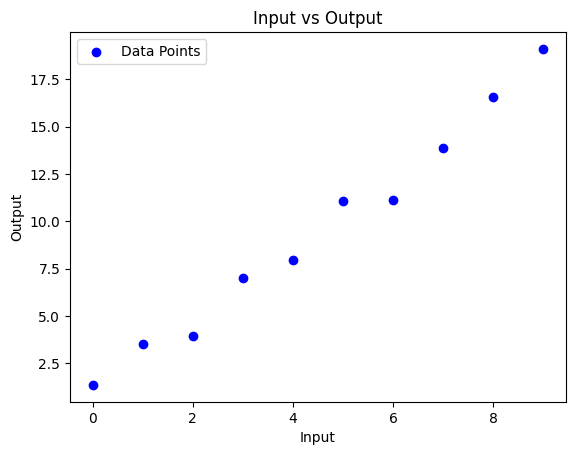

In [36]:
plot_numpyarr(input_arr, output_arr)

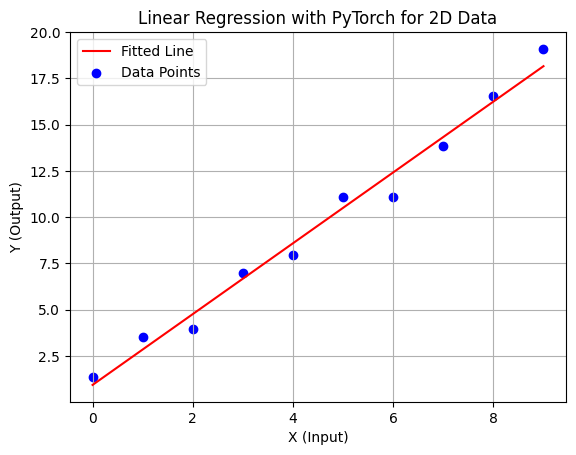

In [43]:
def plot_x_y_predict(model, input_tensor, output_tensor):
    # update model to evaluation mode
    model.eval()
    y_predict_arr = output_tensor.detach().numpy()
    x_predict_arr = input_tensor.detach().numpy()

    plt.plot(x_predict_arr, y_predict_arr, color='red', label='Fitted Line')
    plt.scatter(input_arr, output_arr, color='blue', label='Data Points')
    plt.xlabel('X (Input)')
    plt.ylabel('Y (Output)')
    plt.title('Linear Regression with PyTorch for 2D Data')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_x_y_predict(model, input_tensor,y_predit)

Prediction for input 10.0 is : 20.076221466064453


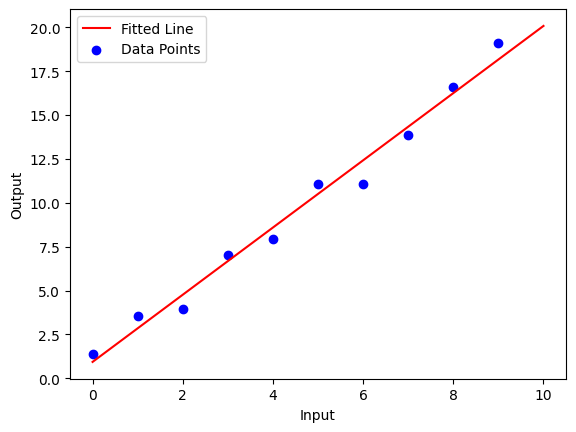

In [ ]:
# now lets make some prediction 

# first we need to stop model from calculating the gradient 
with torch.no_grad():
    x_new = torch.tensor([[10.0]], dtype=torch.float32)
    y_new_pred = model(x_new)
    print(f'Prediction for input {x_new.item()} is : {y_new_pred.item()}')

    # numpy.ndarray has no .append method — use np.append to create new arrays
    x_new_arr = np.append(input_arr, x_new.item())
    y_new_arr = np.append(y_predit.detach().numpy(), y_new_pred.item())

    plt.plot(x_new_arr, y_new_arr, color='red', label='Fitted Line')
    plt.scatter(input_arr, output_arr, color='blue', label='Data Points')
    plt.xlabel('Input')
    plt.ylabel('Output')
    plt.legend()
    plt.show()

In [48]:
x_new_arr

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In [49]:
y_new_arr

array([ 0.93329698,  2.84758949,  4.76188183,  6.67617464,  8.5904665 ,
       10.50475979, 12.41905212, 14.33334446, 16.2476368 , 18.16192818,
       20.07622147])